In [1]:
import pandas as pd

df = pd.read_csv(
    "../data/customer_segments.csv"
)

df.head()

,frequency,monetary,avg_order_value,category_count,avg_review_score,avg_delivery_days,total_freight_paid,recency_days,customer_tenure_days,cluster,customer_segment
0,1,141.90,141.90,1,5.0,6.0,12.00,115,115,2,Active Customers
1,1,27.19,27.19,1,4.0,3.0,8.29,118,118,2,Active Customers
2,1,86.22,86.22,1,3.0,25.0,17.22,541,541,0,Inactive Customers
3,1,43.62,43.62,1,4.0,20.0,17.63,325,325,0,Inactive Customers
4,1,196.89,196.89,1,5.0,13.0,16.89,292,292,0,Inactive Customers


In [2]:
df['clv'] = (
    df['avg_order_value']
    *
    df['frequency']
    *
    (
        df['customer_tenure_days']
        / 365
    )
)

In [3]:
df['clv'].describe()

count    95419.000000
mean       110.685631
std        201.798395
min          0.105205
25%         26.665260
50%         59.664548
75%        122.624521
max      12653.312438
Name: clv, dtype: float64

In [4]:
df.to_csv(
    "../data/customer_clv.csv",
    index=False
)

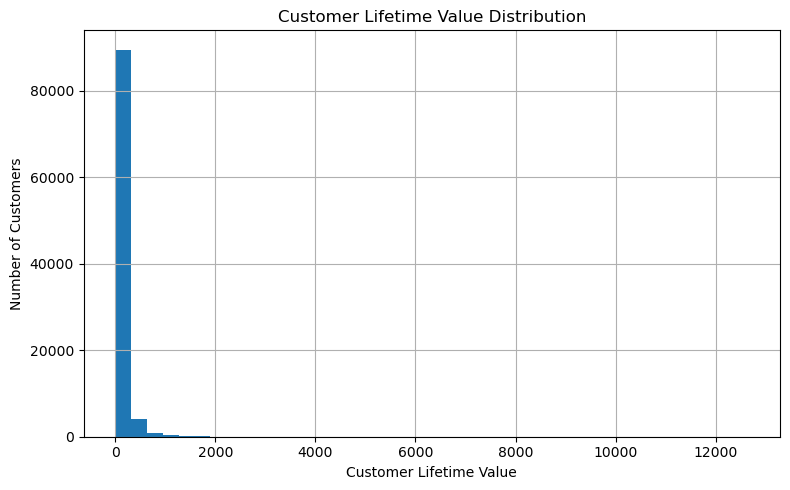

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

df['clv'].hist(
    bins=40
)

plt.title(
    'Customer Lifetime Value Distribution'
)

plt.xlabel(
    'Customer Lifetime Value'
)

plt.ylabel(
    'Number of Customers'
)

plt.tight_layout()

plt.savefig(
    '../visualizations/clv_distribution.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

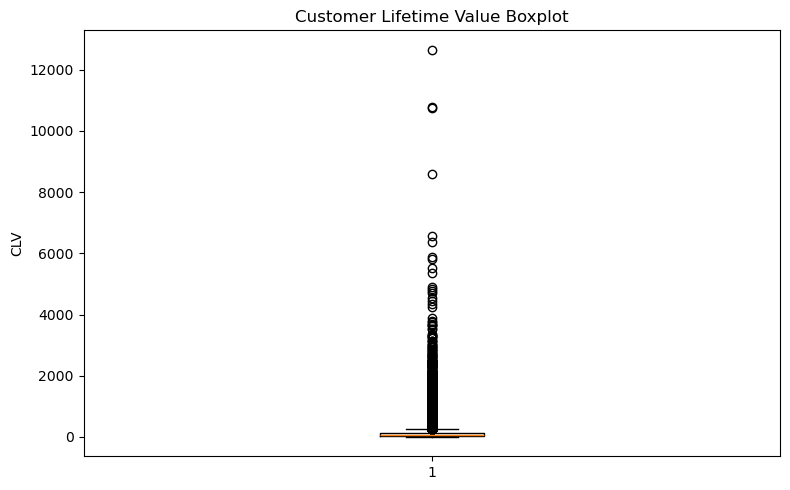

In [6]:
plt.figure(figsize=(8,5))

plt.boxplot(
    df['clv']
)

plt.title(
    'Customer Lifetime Value Boxplot'
)

plt.ylabel(
    'CLV'
)

plt.tight_layout()

plt.savefig(
    '../visualizations/clv_boxplot.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [7]:
segment_clv = (
    df
    .groupby(
        'customer_segment'
    )['clv']
    .mean()
    .sort_values(
        ascending=False
    )
)

segment_clv

customer_segment
VIP Customers             836.208488
Loyal Customers           250.349214
Inactive Customers        149.021302
Dissatisfied Customers     96.690358
Active Customers           46.191579
Name: clv, dtype: float64

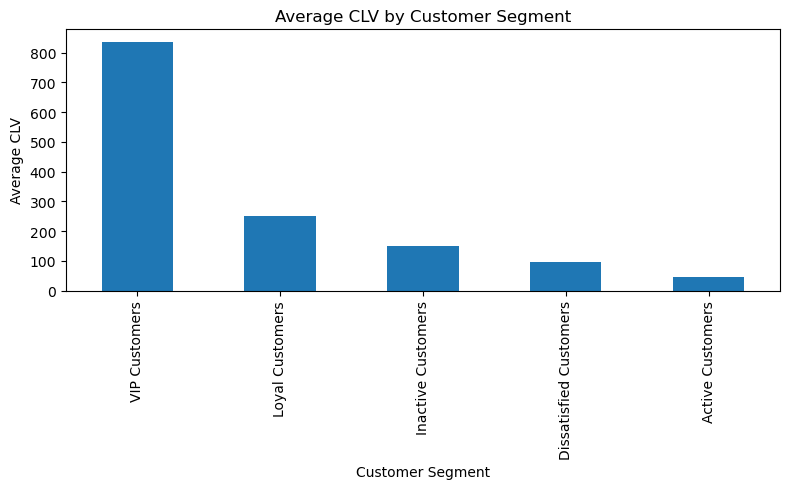

In [8]:
segment_clv.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title(
    'Average CLV by Customer Segment'
)

plt.xlabel(
    'Customer Segment'
)

plt.ylabel(
    'Average CLV'
)

plt.tight_layout()

plt.savefig(
    '../visualizations/clv_by_segment.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [9]:
top_customers = (
    df
    .sort_values(
        'clv',
        ascending=False
    )
    .head(20)
)

top_customers

,frequency,monetary,avg_order_value,category_count,avg_review_score,avg_delivery_days,total_freight_paid,recency_days,customer_tenure_days,cluster,customer_segment,clv
3799,1,109312.64,13664.08,1,1.0,18.0,224.08,338,338,3,VIP Customers,12653.312438
81387,2,7571.63,3785.82,1,5.0,15.0,183.63,519,519,3,VIP Customers,10766.249753
82229,1,6929.31,6929.31,1,5.0,18.0,194.31,567,567,3,VIP Customers,10764.161014
95130,1,6726.66,6726.66,1,5.0,11.0,227.66,466,466,3,VIP Customers,8588.009753
89055,1,4764.34,4764.34,1,4.0,18.0,74.34,502,502,3,VIP Customers,6552.599123
35328,1,4042.74,4042.74,0,5.0,4.0,62.74,575,575,3,VIP Customers,6368.700000
422,1,4016.91,4016.91,1,5.0,5.0,17.01,533,533,3,VIP Customers,5865.789123
34817,1,3736.22,3736.22,1,4.0,12.0,36.23,569,569,3,VIP Customers,5824.408712
1307,1,3602.47,3602.47,1,5.0,7.0,53.47,558,558,3,VIP Customers,5507.337699
33622,2,3559.99,1780.00,1,5.0,16.0,100.99,388,549,3,VIP Customers,5354.630137


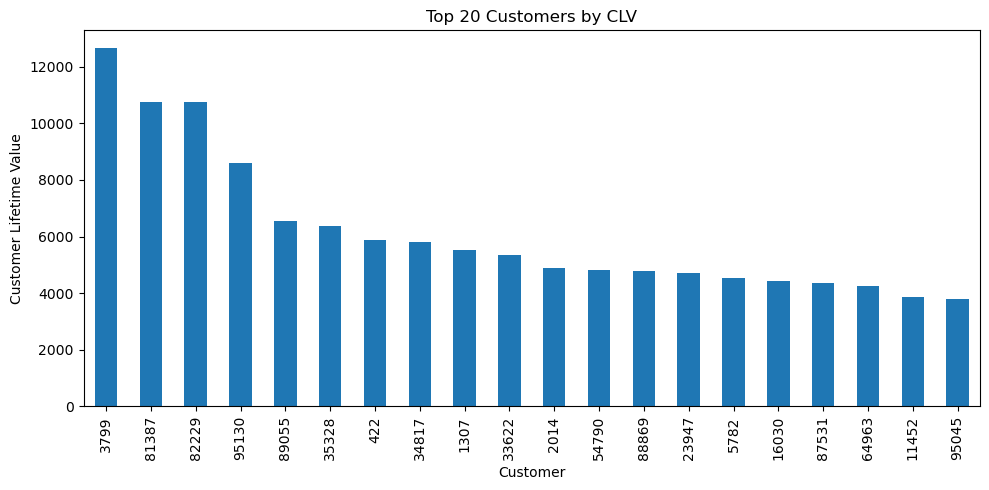

In [10]:
top_customers['clv'].plot(
    kind='bar',
    figsize=(10,5)
)

plt.title(
    'Top 20 Customers by CLV'
)

plt.xlabel(
    'Customer'
)

plt.ylabel(
    'Customer Lifetime Value'
)

plt.tight_layout()

plt.savefig(
    '../visualizations/top_clv_customers.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [11]:
df['clv_segment'] = pd.qcut(
    df['clv'],
    q=4,
    labels=[
        'Low Value',
        'Medium Value',
        'High Value',
        'Premium Value'
    ]
)

In [12]:
df['clv_segment'].value_counts()

clv_segment
Low Value        23855
Medium Value     23855
Premium Value    23855
High Value       23854
Name: count, dtype: int64

1. ### Which customer segment has the highest CLV?
2. ### Which segment should be retained most aggressively?
3. ### Which segment generates the lowest value?

In [13]:
segment_clv = (
    df.groupby('customer_segment')['clv']
      .mean()
      .sort_values(ascending=False)
)

segment_clv

customer_segment
VIP Customers             836.208488
Loyal Customers           250.349214
Inactive Customers        149.021302
Dissatisfied Customers     96.690358
Active Customers           46.191579
Name: clv, dtype: float64